<a href="https://colab.research.google.com/github/crystalclcm/Smartphone-Project/blob/main/Copy_of_Untitled12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Description for chosen data sources

## Smartphone dataset:
- The Kaggle dataset used in this project contains detailed specifications of smartphones, including brand name, model, price, rating, and hardware features such as processor type, RAM, storage, battery capacity, and camera details. It has thousands of rows covering multiple brands like Samsung, Apple, OnePlus, Xiaomi, and others, providing a comprehensive view of the smartphone market. I chose this dataset because it offers technical and pricing information, which is ideal for analyzing trends and comparing devices across different brands.

## Complimentary website:
- I picked GSMArena as the complementary source because it provides brand popularity rankings and the number of models per brand information that isn’t in the Kaggle dataset. Adding this data makes it possible to answer questions like: Do more popular brands charge higher prices? or Does popularity relate to better ratings? This extra layer of data helps connect technical specs and pricing with market trends.

# STEP 1: Import

In [114]:
!pip install pandas

In [115]:
import pandas as pd

# STEP 2: Load Dataset

In [116]:
# Load the Kaggle smartphone dataset into a pandas DataFrame.
# This dataset contains smartphone specifications, prices, and ratings.
df = pd.read_csv('/content/smartphone_dataset.csv')

In [117]:
# Inspect the dataset to understand its structure:
print(df.shape)  # Shows number of rows and columns
print(df.head())  # Displays first 5 rows for a quick preview
print(df.info())  # Displays column names, data types, and missing values


(980, 25)
  brand_name                      model  price  rating  has_5g  has_nfc  \
0    oneplus              OnePlus 11 5G  54999    89.0    True     True   
1    oneplus  OnePlus Nord CE 2 Lite 5G  19989    81.0    True    False   
2    samsung      Samsung Galaxy A14 5G  16499    75.0    True    False   
3   motorola       Motorola Moto G62 5G  14999    81.0    True    False   
4     realme         Realme 10 Pro Plus  24999    82.0    True    False   

   has_ir_blaster processor_brand  num_cores  processor_speed  ...  \
0           False      snapdragon        8.0              3.2  ...   
1           False      snapdragon        8.0              2.2  ...   
2           False          exynos        8.0              2.4  ...   
3           False      snapdragon        8.0              2.2  ...   
4           False       dimensity        8.0              2.6  ...   

   screen_size  refresh_rate    resolution  num_rear_cameras  \
0         6.70           120  1440 x 3216             

# STEP 3: Data Cleaning & Preprocessing

In [118]:
# Normalize brand and model names to lowercase for consistency.
df['brand_name'] = df['brand_name'].str.lower()
df['model'] = df['model'].str.lower()

# Check for missing values
print(df.isnull().sum())


brand_name                     0
model                          0
price                          0
rating                       101
has_5g                         0
has_nfc                        0
has_ir_blaster                 0
processor_brand               20
num_cores                      6
processor_speed               42
battery_capacity              11
fast_charging_available        0
fast_charging                211
ram_capacity                   0
internal_memory                0
screen_size                    0
refresh_rate                   0
resolution                     0
num_rear_cameras               0
num_front_cameras              4
os                            14
primary_camera_rear            0
primary_camera_front           5
extended_memory_available      0
extended_upto                480
dtype: int64


In [119]:
# Drop rows with missing critical values
df = df.dropna()

In [120]:
# Fill missing ratings with the mean rating (if any remain)
df['rating'] = df['rating'].fillna(df['rating'].mean())

In [121]:
# Remove duplicate rows
df = df.drop_duplicates()

In [122]:
# Fill missing processor brand and 5G info with defaults.
df['processor_brand'] = df['processor_brand'].fillna('Unknown')

In [123]:
df['has_5g'] = df['has_5g'].fillna(False)

In [124]:
print(df.dtypes)

brand_name                    object
model                         object
price                          int64
rating                       float64
has_5g                          bool
has_nfc                         bool
has_ir_blaster                  bool
processor_brand               object
num_cores                    float64
processor_speed              float64
battery_capacity             float64
fast_charging_available        int64
fast_charging                float64
ram_capacity                 float64
internal_memory              float64
screen_size                  float64
refresh_rate                   int64
resolution                    object
num_rear_cameras               int64
num_front_cameras            float64
os                            object
primary_camera_rear          float64
primary_camera_front         float64
extended_memory_available      int64
extended_upto                float64
dtype: object


In [125]:
# Convert price column to numeric (handles any non-numeric values)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [126]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
Index: 352 entries, 1 to 976
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 352 non-null    object 
 1   model                      352 non-null    object 
 2   price                      352 non-null    int64  
 3   rating                     352 non-null    float64
 4   has_5g                     352 non-null    bool   
 5   has_nfc                    352 non-null    bool   
 6   has_ir_blaster             352 non-null    bool   
 7   processor_brand            352 non-null    object 
 8   num_cores                  352 non-null    float64
 9   processor_speed            352 non-null    float64
 10  battery_capacity           352 non-null    float64
 11  fast_charging_available    352 non-null    int64  
 12  fast_charging              352 non-null    float64
 13  ram_capacity               352 non-null    float64
 14 

In [127]:
print(df.columns.tolist())


['brand_name', 'model', 'price', 'rating', 'has_5g', 'has_nfc', 'has_ir_blaster', 'processor_brand', 'num_cores', 'processor_speed', 'battery_capacity', 'fast_charging_available', 'fast_charging', 'ram_capacity', 'internal_memory', 'screen_size', 'refresh_rate', 'resolution', 'num_rear_cameras', 'num_front_cameras', 'os', 'primary_camera_rear', 'primary_camera_front', 'extended_memory_available', 'extended_upto']


In [128]:
display(df.head())

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,...,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
1,oneplus,oneplus nord ce 2 lite 5g,19989,81.0,True,False,False,snapdragon,8.0,2.2,...,6.59,120,1080 x 2412,3,1.0,android,64.0,16.0,1,1024.0
2,samsung,samsung galaxy a14 5g,16499,75.0,True,False,False,exynos,8.0,2.4,...,6.60,90,1080 x 2408,3,1.0,android,50.0,13.0,1,1024.0
5,samsung,samsung galaxy f23 5g (6gb ram + 128gb),16999,80.0,True,True,False,snapdragon,8.0,2.2,...,6.60,120,1080 x 2408,3,1.0,android,50.0,8.0,1,1024.0
10,realme,realme 10 pro,18999,82.0,True,False,False,snapdragon,8.0,2.2,...,6.72,120,1080 x 2400,2,1.0,android,108.0,16.0,1,1024.0
13,vivo,vivo t1 5g (6gb ram + 128gb),16990,80.0,True,False,False,snapdragon,8.0,2.2,...,6.58,120,1080 x 2408,3,1.0,android,50.0,16.0,1,1024.0


In [129]:
# Drop rows where price or rating is missing after conversion
df = df.dropna(subset=['price','rating'])

# STEP 4: Aggregate Kaggle Data by Brand

In [130]:
# Group data by brand to calculate average price and rating for each brand
# This simplifies analysis and makes merging with GSMArena data easier

brand_stats = df.groupby('brand_name').agg({'price':'mean','rating':'mean'}).reset_index()

In [131]:
display(df.head())

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,...,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
1,oneplus,oneplus nord ce 2 lite 5g,19989,81.0,True,False,False,snapdragon,8.0,2.2,...,6.59,120,1080 x 2412,3,1.0,android,64.0,16.0,1,1024.0
2,samsung,samsung galaxy a14 5g,16499,75.0,True,False,False,exynos,8.0,2.4,...,6.60,90,1080 x 2408,3,1.0,android,50.0,13.0,1,1024.0
5,samsung,samsung galaxy f23 5g (6gb ram + 128gb),16999,80.0,True,True,False,snapdragon,8.0,2.2,...,6.60,120,1080 x 2408,3,1.0,android,50.0,8.0,1,1024.0
10,realme,realme 10 pro,18999,82.0,True,False,False,snapdragon,8.0,2.2,...,6.72,120,1080 x 2400,2,1.0,android,108.0,16.0,1,1024.0
13,vivo,vivo t1 5g (6gb ram + 128gb),16990,80.0,True,False,False,snapdragon,8.0,2.2,...,6.58,120,1080 x 2408,3,1.0,android,50.0,16.0,1,1024.0


In [132]:
brand_stats = df.groupby('brand_name').agg({'price':'mean','rating':'mean'}).reset_index()
display(brand_stats.head())


,brand_name,price,rating
0,cola,14999.0,74.0
1,doogee,30499.0,86.0
2,honor,14990.0,75.0
3,huawei,130994.5,81.0
4,infinix,15158.8,77.8


# STEP 5: Web Scraping GSMArena Data

In [133]:
import urllib.request
from bs4 import BeautifulSoup


In [134]:
# GSMArena provides brand popularity rankings and model counts.
# We scrape this data to complement the Kaggle dataset.
url = 'https://www.gsmarena.com/stats.php3'
response = urllib.request.urlopen(url)   # Open the URL
html = response.read()                   # Read the HTML content

In [135]:
soup = BeautifulSoup(html, 'html.parser')

In [136]:
# Locate the first table on the page and extract all rows
table = soup.find('table')  # Finds the first table
rows = table.find_all('tr') # Get all rows

In [137]:
# Parse rows into a list of lists (brand, rank, popularity score, model count
data = []
for row in rows[1:]:  # skip header
    cols = row.find_all('td')
    if len(cols) >= 4:
        rank = cols[0].text.strip()
        brand = cols[1].text.strip()       # Correct brand column
        popularity = cols[2].text.strip()  # Popularity score
        models_count = cols[3].text.strip()
        data.append([brand, rank, popularity, models_count])


In [138]:
# Convert scraped data into a DataFrame.
df_gsmarena = pd.DataFrame(data, columns=['brand_name','popularity_rank','models_count'])

In [139]:
# Clean brand names and convert numeric columns for analysis
df_gsmarena['brand_name'] = df_gsmarena['brand_name'].str.lower().str.strip()
df_gsmarena['popularity_rank'] = pd.to_numeric(df_gsmarena['popularity_rank'], errors='coerce')
df_gsmarena['models_count'] = pd.to_numeric(df_gsmarena['models_count'], errors='coerce')


In [140]:
# Normalize brand names in both datasets for consistency
df['brand_name'] = df['brand_name'].str.strip().str.lower()
df_gsmarena['brand_name'] = df_gsmarena['brand_name'].str.strip().str.lower()



In [141]:
print("Kaggle brands:", df['brand_name'].unique())
print("GSMArena brands:", df_gsmarena['brand_name'].unique())


Kaggle brands: ['oneplus' 'samsung' 'realme' 'vivo' 'poco' 'xiaomi' 'oppo' 'motorola'
 'jio' 'iqoo' 'infinix' 'cola' 'tecno' 'redmi' 'nokia' 'huawei' 'sony'
 'lava' 'itel' 'doogee' 'honor']
GSMArena brands: []


In [142]:
tables = pd.read_html('https://www.gsmarena.com/stats.php3')
print(len(tables))  # Check how many tables
df_gsmarena = tables[0]  # First table
print(df_gsmarena.head())


3
   Unnamed: 0                    Phones   Hits  Unnamed: 3
0         1.0                OnePlus 15  41202         NaN
1         2.0  Samsung Galaxy Z TriFold  28251         NaN
2         3.0        Samsung Galaxy A56  25732         NaN
3         4.0  Samsung Galaxy S25 Ultra  24202         NaN
4         5.0         Xiaomi 17 Pro Max  23713         NaN


In [143]:
# Rename columns
df_gsmarena.columns = ['popularity_rank','brand_name','popularity_score','models_count']

# Clean brand names (string column)
df_gsmarena['brand_name'] = df_gsmarena['brand_name'].str.lower().str.strip()

# Convert numeric columns (no .str needed because they are already numeric or convertible)
df_gsmarena['popularity_rank'] = pd.to_numeric(df_gsmarena['popularity_rank'], errors='coerce')
df_gsmarena['popularity_score'] = pd.to_numeric(df_gsmarena['popularity_score'], errors='coerce')
df_gsmarena['models_count'] = pd.to_numeric(df_gsmarena['models_count'], errors='coerce')


In [144]:
print(df_gsmarena.head())
print(df_gsmarena.dtypes)


   popularity_rank                brand_name  popularity_score  models_count
0              1.0                oneplus 15             41202           NaN
1              2.0  samsung galaxy z trifold             28251           NaN
2              3.0        samsung galaxy a56             25732           NaN
3              4.0  samsung galaxy s25 ultra             24202           NaN
4              5.0         xiaomi 17 pro max             23713           NaN
popularity_rank     float64
brand_name           object
popularity_score      int64
models_count        float64
dtype: object


In [152]:
df['brand_name'] = df['brand_name'].str.strip().str.lower()
df_gsmarena['brand_name'] = df_gsmarena['brand_name'].str.strip().str.lower()
df_gsmarena['brand_name'] = df_gsmarena['brand_name'].str.split().str[0].str.lower().str.strip()
brand_stats['brand_name'] = brand_stats['brand_name'].str.strip().str.lower()


# STEP 6: Merge Kaggle and GSMArena Data

In [153]:
# Merge the two datasets on brand_name to combine average price/rating with popularity rank.
merged_df = pd.merge(brand_stats, df_gsmarena, on='brand_name', how='inner')
print(merged_df.head())


  brand_name         price     rating  popularity_rank  popularity_score  \
0    oneplus  21320.625000  79.500000              1.0             41202   
1       oppo  20790.517241  80.517241              7.0             21160   
2       oppo  20790.517241  80.517241             17.0             13614   
3    samsung  23367.787879  79.287879              2.0             28251   
4    samsung  23367.787879  79.287879              3.0             25732   

   models_count  
0           NaN  
1           NaN  
2           NaN  
3           NaN  
4           NaN  


How the merge works:

This join keeps only rows where the brand exists in both datasets. It combines the Kaggle data (average price and rating) with GSMArena data (popularity rank, popularity score, and model count) into one table. The result is a single dataset where each row represents a brand with all relevant metrics side by side, making it easy to analyze relationships between price, rating, and popularity.

Issue i had to fix:

After merging the two datasets, a few problems came up:

Some brands in the Kaggle dataset didn’t appear in GSMArena, so those rows were dropped during the inner join.
Brand names were inconsistent (different cases, extra spaces, or longer names like “Samsung Electronics”), which caused the initial merge to fail.

A few columns from the scraped data had text instead of numbers, so they needed conversion.

These issues were fixed through cleaning and normalization.



how it was fixed:

The issue was fixed by normalizing and cleaning the brand_name column in both datasets before merging. This can be found just before merging

What these steps do:

- .str.lower()  Converts all names to lowercase for consistency.
- .str.strip() Removes leading spaces.
- .str.split().str[0] Takes only the first word of the brand name (important because GSMArena sometimes lists full names like “Samsung Electronics”).

# STEP 7: Correlation Analysis

In [102]:
# Calculate correlation between popularity rank, price, and rating.
# Helps quantify relationships between these variables.

print(merged_df[['popularity_rank','price','rating']].corr())

                 popularity_rank     price    rating
popularity_rank         1.000000 -0.255470 -0.178207
price                  -0.255470  1.000000  0.769382
rating                 -0.178207  0.769382  1.000000


# STEP 8: Visualizations

# Regression Plot: Popularity vs Price/ Popularity vs Rating

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns


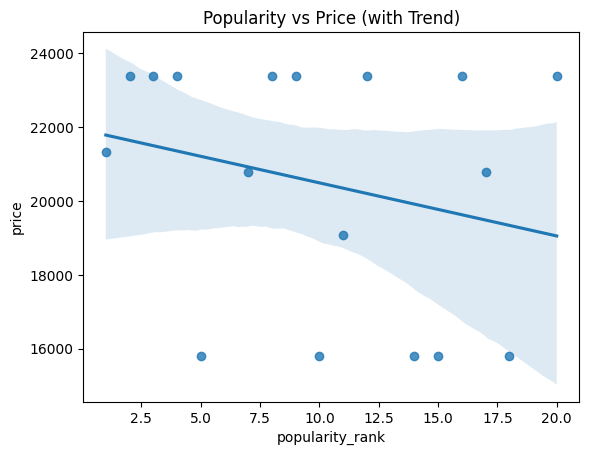

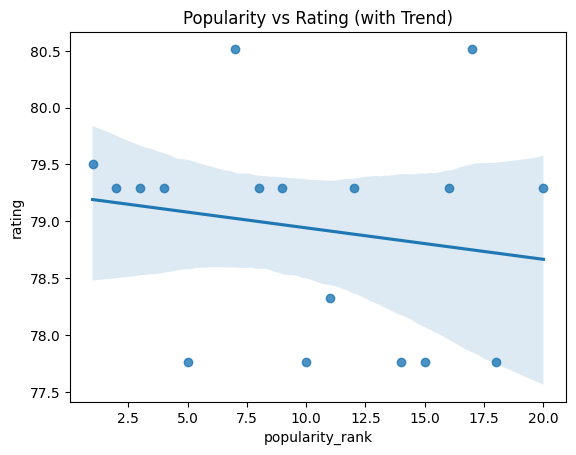

In [108]:
sns.regplot(data=merged_df, x='popularity_rank', y='price')
plt.title('Popularity vs Price (with Trend)')
plt.show()

sns.regplot(data=merged_df, x='popularity_rank', y='rating')
plt.title('Popularity vs Rating (with Trend)')
plt.show()


# Bar chart: Average price per brand sorted by popularity rank.

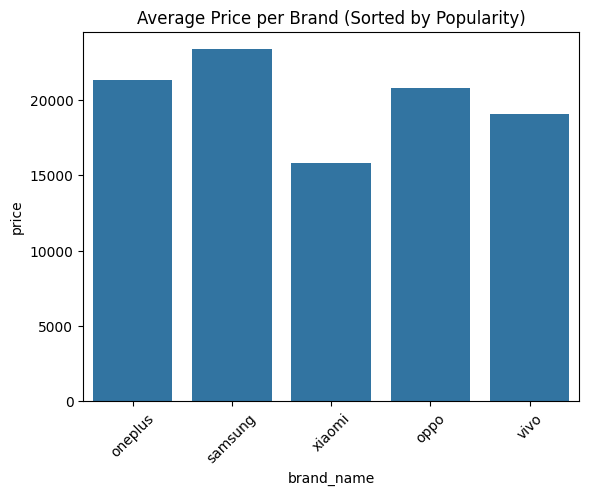

In [91]:
sns.barplot(data=merged_df.sort_values('popularity_rank'), x='brand_name', y='price')
plt.title('Average Price per Brand (Sorted by Popularity)')
plt.xticks(rotation=45)
plt.show()


# Questions / Observations from charts

Does brand popularity correlate with smartphone price?

Observation from Regression Plot:
- The trend line slopes downward, indicating a negative correlation between popularity rank and price.
- Brands with lower popularity rank (more popular) tend to have slightly higher prices than less popular brands. However, the spread of points shows variability, meaning popularity is not the only factor influencing price.
- Popular brands like Samsung and OnePlus maintain higher average prices, while mid-tier brands (e.g., Xiaomi) offer more affordable options.
- Popularity rank has a moderate negative relationship with price, but the effect is not strong.

Does brand popularity correlate with smartphone rating?

Observation from Regression Plot:
- The trend line is almost flat with a slight downward slope, indicating very weak negative correlation.
- Popular brands do not consistently have higher ratings.
- Ratings cluster between 77.5 and 80.5 regardless of popularity rank.
- Popularity does not strongly predict rating.
- Popularity rank has very low impact on ratings

How do different brands compare in terms of average price?

Observation from Bar Chart:
- Samsung has the highest average price among the top brands.
- OnePlus and Oppo follow closely.
- Xiaomi has the lowest average price, making it the most budget-friendly among popular brands.
- Premium pricing is associated with Samsung and OnePlus, while Xiaomi targets affordability.
- There is a clear price segmentation among brands.

Do higher-priced smartphones tend to have higher ratings?
- From the regression plots and correlation analysis, the relationship between price and rating is weak.
- Higher price does not guarantee higher rating.
- Consumers value factors beyond price, such as features and brand trust.
- Price and rating are not strongly linked.